In [2]:
# Data Cleaning & Reporting Automation

## Project Objective

#The objective of this project is to automate a data cleaning and reporting workflow using Python. The project identifies and resolves common data quality issues such as missing values, duplicate records, inconsistent categorical data, and invalid values.

#The cleaned dataset is then exported to Excel and summarized through automated reports and visualizations.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# Creating a sample retail sales dataset

sales_data = {
    "Order_ID": [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010,
                 1011, 1012, 1013, 1014, 1015],

    "Customer": [
        "Aarav Sharma", "Priya Mehta", " Rohan Shah", "Neha Patel",
        "Aarav Sharma", "Vikram Singh", "Ananya Gupta", "Priya Mehta",
        "Kabir Jain", "Meera Joshi", "Rohan Shah", "Ananya Gupta",
        "Vikram Singh", "Meera Joshi", "Kabir Jain"
    ],

    "Product": [
        "Laptop", "Chair", "Phone", "Table", "Laptop",
        "Headphones", "Keyboard", "Chair", "Monitor", "Phone",
        "Phone", "Keyboard", "Laptop", "Table", "Monitor"
    ],

    "Category": [
        "Electronics", "furniture", " ELECTRONICS", "Furniture",
        "electronics", "Electronics", "electronics", "FURNITURE",
        "Electronics", " electronics", "Electronics", "Electronics",
        "Electronics", "furniture", "ELECTRONICS"
    ],

    "Region": [
        "West", "North", "south", "East", "West",
        "North", " west ", "NORTH", "South", "east",
        "South", "West", "North", "East", "South"
    ],

    "Sales": [
        55000, 12000, np.nan, 18000, 55000,
        3500, 2500, 12500, 22000, np.nan,
        16000, 3000, 62000, 19500, 24000
    ],

    "Quantity": [
        2, 3, 1, np.nan, 2,
        4, 5, 3, 2, 1,
        2, 4, 1, 2, 3
    ],

    "Order_Date": [
        "2026-01-10", "2026-01-12", "2026-01-15", "2026-01-18",
        "2026-01-10", "2026-01-20", "2026-01-22", "2026-01-25",
        "2026-01-28", "2026-02-01", "2026-02-04", "2026-02-07",
        "2026-02-10", "2026-02-12", "2026-02-15"
    ]
}

raw_df = pd.DataFrame(sales_data)

raw_df

,Order_ID,Customer,Product,Category,Region,Sales,Quantity,Order_Date
0,1001,Aarav Sharma,Laptop,Electronics,West,55000.0,2.0,2026-01-10
1,1002,Priya Mehta,Chair,furniture,North,12000.0,3.0,2026-01-12
2,1003,Rohan Shah,Phone,ELECTRONICS,south,NaN,1.0,2026-01-15
3,1004,Neha Patel,Table,Furniture,East,18000.0,NaN,2026-01-18
4,1005,Aarav Sharma,Laptop,electronics,West,55000.0,2.0,2026-01-10
5,1006,Vikram Singh,Headphones,Electronics,North,3500.0,4.0,2026-01-20
6,1007,Ananya Gupta,Keyboard,electronics,west,2500.0,5.0,2026-01-22
7,1008,Priya Mehta,Chair,FURNITURE,NORTH,12500.0,3.0,2026-01-25
8,1009,Kabir Jain,Monitor,Electronics,South,22000.0,2.0,2026-01-28
9,1010,Meera Joshi,Phone,electronics,east,NaN,1.0,2026-02-01


In [6]:
# Adding a duplicate record to demonstrate duplicate detection

raw_df = pd.concat(
    [raw_df, raw_df.iloc[[0]]],
    ignore_index=True
)

print("Dataset shape:", raw_df.shape)

Dataset shape: (16, 8)


In [8]:
import os

# Create required project folders if they do not already exist
os.makedirs("data", exist_ok=True)
os.makedirs("reports", exist_ok=True)
os.makedirs("screenshots", exist_ok=True)

# Save the raw dataset
raw_df.to_excel(
    "data/raw_sales_data.xlsx",
    index=False
)

print("Raw dataset saved successfully.")

Raw dataset saved successfully.


In [9]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
C:\Users\ASUS\Data_Cleaning_Reporting_Automation


In [10]:
print(os.listdir())

['.ipynb_checkpoints', 'data', 'Data_Cleaning_Reporting_Automation.ipynb', 'reports', 'screenshots']


In [11]:
print(os.listdir("data"))

['raw_sales_data.xlsx']


In [12]:
## 1. Loading the Raw Dataset

#The raw retail sales data is loaded from an Excel file for further inspection and processing.

In [13]:
df = pd.read_excel("data/raw_sales_data.xlsx")

print("Dataset loaded successfully.")
print(f"Number of records: {len(df)}")
print(f"Number of columns: {len(df.columns)}")

Dataset loaded successfully.
Number of records: 16
Number of columns: 8


In [14]:
## 2. Initial Data Inspection

#The dataset is inspected to understand its structure, columns, data types, and initial records before performing any cleaning operations.

In [15]:
df.head()

,Order_ID,Customer,Product,Category,Region,Sales,Quantity,Order_Date
0,1001,Aarav Sharma,Laptop,Electronics,West,55000.0,2.0,2026-01-10
1,1002,Priya Mehta,Chair,furniture,North,12000.0,3.0,2026-01-12
2,1003,Rohan Shah,Phone,ELECTRONICS,south,NaN,1.0,2026-01-15
3,1004,Neha Patel,Table,Furniture,East,18000.0,NaN,2026-01-18
4,1005,Aarav Sharma,Laptop,electronics,West,55000.0,2.0,2026-01-10


In [16]:
print("Dataset dimensions:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Dataset dimensions: (16, 8)

Column names:
['Order_ID', 'Customer', 'Product', 'Category', 'Region', 'Sales', 'Quantity', 'Order_Date']


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_ID    16 non-null     int64  
 1   Customer    16 non-null     str    
 2   Product     16 non-null     str    
 3   Category    16 non-null     str    
 4   Region      16 non-null     str    
 5   Sales       14 non-null     float64
 6   Quantity    15 non-null     float64
 7   Order_Date  16 non-null     str    
dtypes: float64(2), int64(1), str(5)
memory usage: 1.8 KB


In [18]:
## 3. Data Quality Assessment

#The raw dataset is checked for missing values, duplicate records, and inconsistent categorical values.

In [19]:
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

Missing values by column:
Order_ID      0
Customer      0
Product       0
Category      0
Region        0
Sales         2
Quantity      1
Order_Date    0
dtype: int64


In [20]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 1


In [21]:
print("Category values:")
print(df["Category"].unique())

print("\nRegion values:")
print(df["Region"].unique())

Category values:
<ArrowStringArray>
[ 'Electronics',    'furniture', ' ELECTRONICS',    'Furniture',
  'electronics',    'FURNITURE', ' electronics',  'ELECTRONICS']
Length: 8, dtype: str

Region values:
<ArrowStringArray>
['West', 'North', 'south', 'East', ' west ', 'NORTH', 'South', 'east']
Length: 8, dtype: str


In [23]:
## 4. Automated Data Cleaning

#The identified data quality issues are handled programmatically to create a consistent and analysis-ready dataset.

In [24]:
# Keep a copy of the original dataset for comparison

clean_df = df.copy()

print("Working copy created.")

Working copy created.


In [25]:
### 4.1 Standardizing Column Names

In [26]:
clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Updated column names:")
print(clean_df.columns.tolist())

Updated column names:
['order_id', 'customer', 'product', 'category', 'region', 'sales', 'quantity', 'order_date']


In [27]:
### 4.2 Handling Missing Values

#Numerical missing values are replaced using the median, while missing categorical values are labelled as `Unknown`.

In [28]:
# Record missing values before cleaning
missing_before = clean_df.isnull().sum().sum()

print("Total missing values before cleaning:", missing_before)

Total missing values before cleaning: 3


In [29]:
categorical_columns = [
    "customer",
    "product",
    "category",
    "region"
]

for column in categorical_columns:
    clean_df[column] = clean_df[column].fillna("Unknown")

In [30]:
numeric_columns = [
    "sales",
    "quantity"
]

for column in numeric_columns:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].median()
    )

In [31]:
print("Missing values after treatment:")
print(clean_df.isnull().sum())

Missing values after treatment:
order_id      0
customer      0
product       0
category      0
region        0
sales         0
quantity      0
order_date    0
dtype: int64


In [32]:
### 4.3 Standardizing Text Values

#Text fields are normalized by removing unnecessary spaces and applying consistent capitalization.

In [33]:
text_columns = [
    "customer",
    "product",
    "category",
    "region"
]

for column in text_columns:
    clean_df[column] = (
        clean_df[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

In [34]:
clean_df["category"] = clean_df["category"].replace({
    "electronics": "Electronics",
    "furniture": "Furniture"
})

In [35]:
clean_df["region"] = clean_df["region"].str.title()

In [36]:
print("Categories after standardization:")
print(clean_df["category"].unique())

print("\nRegions after standardization:")
print(clean_df["region"].unique())

Categories after standardization:
<ArrowStringArray>
['Electronics', 'Furniture']
Length: 2, dtype: str

Regions after standardization:
<ArrowStringArray>
['West', 'North', 'South', 'East']
Length: 4, dtype: str


In [37]:
### 4.4 Removing Duplicate Records

In [38]:
duplicates_before = clean_df.duplicated().sum()

clean_df = clean_df.drop_duplicates().reset_index(drop=True)

duplicates_after = clean_df.duplicated().sum()

print("Duplicates before cleaning:", duplicates_before)
print("Duplicates after cleaning:", duplicates_after)

Duplicates before cleaning: 1
Duplicates after cleaning: 0


In [39]:
### 4.5 Date Validation

In [40]:
clean_df["order_date"] = pd.to_datetime(
    clean_df["order_date"],
    errors="coerce"
)

invalid_dates = clean_df["order_date"].isnull().sum()

print("Invalid date values:", invalid_dates)

Invalid date values: 0


In [41]:
### 4.6 Numerical Data Validation

In [42]:
invalid_sales = (clean_df["sales"] < 0).sum()
invalid_quantity = (clean_df["quantity"] <= 0).sum()

print("Negative sales values:", invalid_sales)
print("Invalid quantity values:", invalid_quantity)

Negative sales values: 0
Invalid quantity values: 0


In [43]:
## 5. Final Data Quality Check

In [44]:
print("FINAL DATA QUALITY CHECK")
print("-" * 30)

print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))
print("Missing values:", clean_df.isnull().sum().sum())
print("Duplicate records:", clean_df.duplicated().sum())

FINAL DATA QUALITY CHECK
------------------------------
Rows: 15
Columns: 8
Missing values: 0
Duplicate records: 0


In [45]:
clean_df.head(10)

,order_id,customer,product,category,region,sales,quantity,order_date
0,1001,aarav sharma,laptop,Electronics,West,55000.0,2.0,2026-01-10
1,1002,priya mehta,chair,Furniture,North,12000.0,3.0,2026-01-12
2,1003,rohan shah,phone,Electronics,South,18750.0,1.0,2026-01-15
3,1004,neha patel,table,Furniture,East,18000.0,2.0,2026-01-18
4,1005,aarav sharma,laptop,Electronics,West,55000.0,2.0,2026-01-10
5,1006,vikram singh,headphones,Electronics,North,3500.0,4.0,2026-01-20
6,1007,ananya gupta,keyboard,Electronics,West,2500.0,5.0,2026-01-22
7,1008,priya mehta,chair,Furniture,North,12500.0,3.0,2026-01-25
8,1009,kabir jain,monitor,Electronics,South,22000.0,2.0,2026-01-28
9,1010,meera joshi,phone,Electronics,East,18750.0,1.0,2026-02-01


In [46]:
## 6. Automated Data Quality Report

#A summary report is generated automatically to document the changes performed during the data cleaning process.

In [47]:
# Calculate final cleaning statistics

original_rows = len(df)
cleaned_rows = len(clean_df)

missing_after = clean_df.isnull().sum().sum()

rows_removed = original_rows - cleaned_rows

print("Original records:", original_rows)
print("Final records:", cleaned_rows)
print("Records removed:", rows_removed)
print("Missing values remaining:", missing_after)
print("Duplicate records remaining:", clean_df.duplicated().sum())

Original records: 16
Final records: 15
Records removed: 1
Missing values remaining: 0
Duplicate records remaining: 0


In [48]:
# Create an automated data quality summary

report_data = {
    "Metric": [
        "Original Records",
        "Final Records",
        "Records Removed",
        "Missing Values Before Cleaning",
        "Missing Values After Cleaning",
        "Duplicate Records Before Cleaning",
        "Duplicate Records After Cleaning",
        "Invalid Dates",
        "Negative Sales Values",
        "Invalid Quantity Values"
    ],
    
    "Result": [
        original_rows,
        cleaned_rows,
        rows_removed,
        missing_before,
        missing_after,
        duplicates_before,
        duplicates_after,
        invalid_dates,
        invalid_sales,
        invalid_quantity
    ]
}

quality_report = pd.DataFrame(report_data)

quality_report

,Metric,Result
0,Original Records,16
1,Final Records,15
2,Records Removed,1
3,Missing Values Before Cleaning,3
4,Missing Values After Cleaning,0
5,Duplicate Records Before Cleaning,1
6,Duplicate Records After Cleaning,0
7,Invalid Dates,0
8,Negative Sales Values,0
9,Invalid Quantity Values,0


In [49]:
### 6.1 Column-Level Data Quality Summary

In [50]:
column_quality = pd.DataFrame({
    "Column": df.columns,
    "Missing Before": df.isnull().sum().values,
    "Missing After": clean_df.isnull().sum().values,
    "Data Type": clean_df.dtypes.astype(str).values
})

column_quality

,Column,Missing Before,Missing After,Data Type
0,Order_ID,0,0,int64
1,Customer,0,0,str
2,Product,0,0,str
3,Category,0,0,str
4,Region,0,0,str
5,Sales,2,0,float64
6,Quantity,1,0,float64
7,Order_Date,0,0,datetime64[us]


In [51]:
## 7. Exporting Automated Reports

#The generated quality metrics and column-level analysis are exported to an Excel workbook for reporting and future reference.

In [53]:
# Export multiple report sheets into one Excel workbook

with pd.ExcelWriter("reports/data_quality_report.xlsx", engine="openpyxl") as writer:
    quality_report.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )
    
    column_quality.to_excel(
        writer,
        sheet_name="Column Analysis",
        index=False
    )

print("Automated Excel report generated successfully.")

Automated Excel report generated successfully.


In [54]:
## 8. Exporting the Clean Dataset

In [55]:
# Export cleaned dataset

clean_df.to_excel(
    "data/cleaned_sales_data.xlsx",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


In [56]:
import os

print("Files in data folder:")
print(os.listdir("data"))

print("\nFiles in reports folder:")
print(os.listdir("reports"))

Files in data folder:
['cleaned_sales_data.xlsx', 'raw_sales_data.xlsx']

Files in reports folder:
['data_quality_report.xlsx']


In [57]:
## 9. Visual Data Analysis

#Visualizations are created from the cleaned dataset to identify sales patterns across product categories and regions.

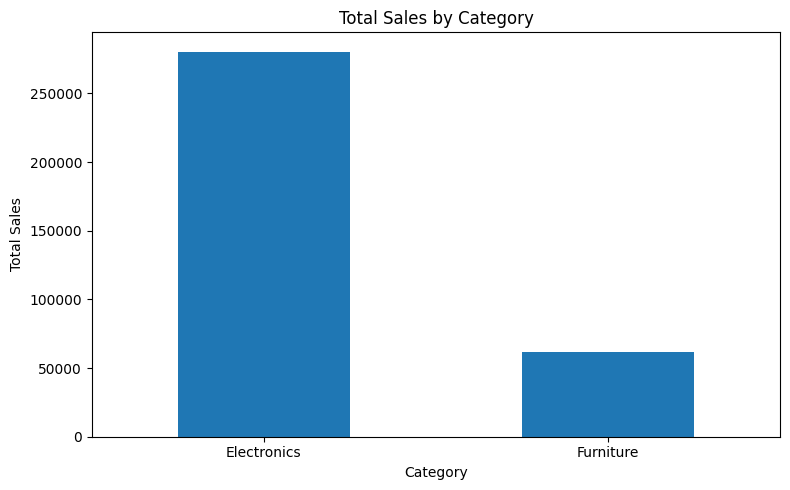

In [58]:
category_sales = clean_df.groupby("category")["sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "screenshots/sales_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

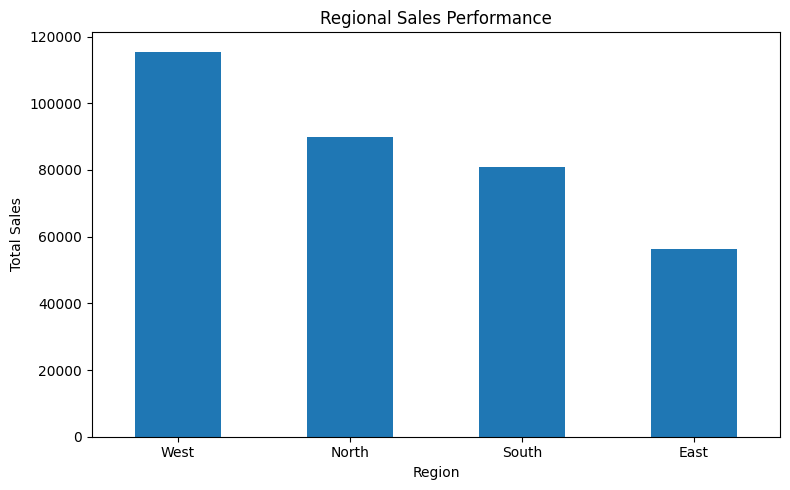

In [59]:
regional_sales = clean_df.groupby("region")["sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

regional_sales.plot(kind="bar")

plt.title("Regional Sales Performance")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "screenshots/regional_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

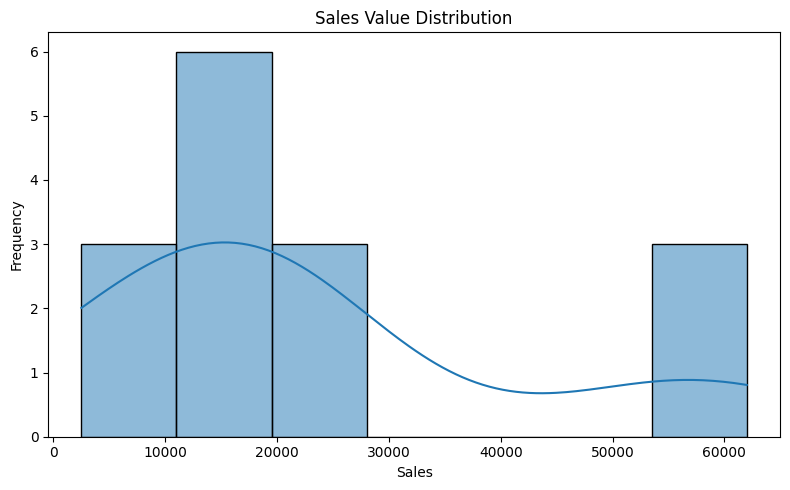

In [60]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=clean_df,
    x="sales",
    kde=True
)

plt.title("Sales Value Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    "screenshots/sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

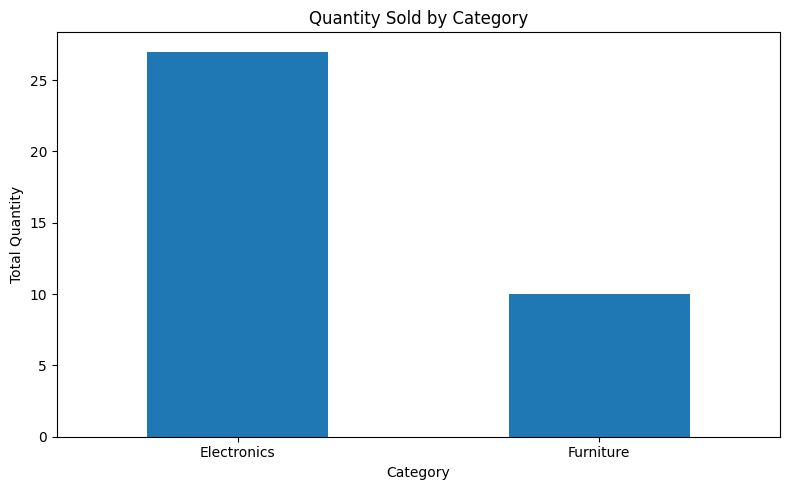

In [61]:
category_quantity = clean_df.groupby("category")["quantity"].sum()

plt.figure(figsize=(8, 5))

category_quantity.plot(kind="bar")

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Quantity")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "screenshots/quantity_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
## 10. Final Summary

#The data cleaning and reporting workflow successfully processed the raw retail sales dataset.

#The project identified and handled missing values, duplicate records, inconsistent text formatting, and invalid data. The cleaned dataset was exported to Excel along with an automated data quality report.

#Visual summaries were also generated to analyze sales performance across categories and regions.

#This workflow demonstrates how Python can be used to automate repetitive data cleaning and reporting activities.